In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ev_dataset.csv to ev_dataset (2).csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
data = pd.read_csv("ev_dataset.csv")

# Display first rows
print("Dataset Preview:")
print(data.head())

# Features (input variables)
X = data[['battery_capacity_kWh', 'vehicle_weight_kg', 'avg_speed_kmph', 'temperature_C']]

# Target (output)
y = data['range_km']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict test values
predictions = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("\nModel Performance")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

# Predict range for a new EV
# Convert new_ev to a DataFrame with column names for consistency
new_ev_data = [[80, 1900, 75, 30]]
new_ev_df = pd.DataFrame(new_ev_data, columns=X.columns)

predicted_range = model.predict(new_ev_df)

print("\nPredicted EV Range:", predicted_range[0], "km")


Dataset Preview:
   battery_capacity_kWh  vehicle_weight_kg  avg_speed_kmph  temperature_C  \
0                    40               1500              60             25   
1                    50               1600              70             30   
2                    60               1700              65             28   
3                    75               1800              80             32   
4                    90               2000              75             35   

   range_km  
0       250  
1       300  
2       350  
3       420  
4       480  

Model Performance
Mean Absolute Error: 3.940706970906765
Mean Squared Error: 16.456553454171566

Predicted EV Range: 431.1891110562058 km



Predicted EV Range: 431.1891110562058 km


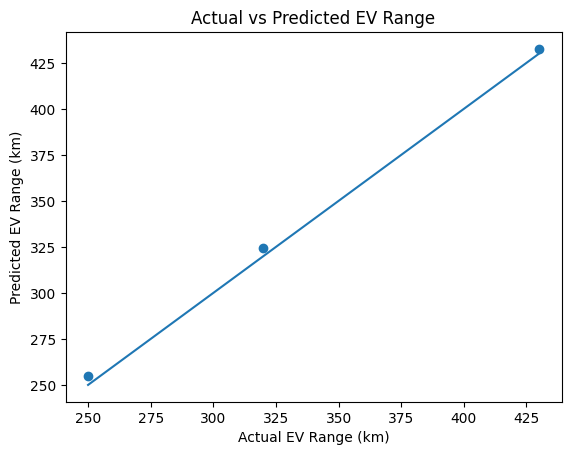

In [ ]:
new_ev_data = [[80, 1900, 75, 30]]
new_ev_df = pd.DataFrame(new_ev_data, columns=X.columns)

predicted_range = model.predict(new_ev_df)

print("\nPredicted EV Range:", predicted_range[0], "km")
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values
plt.figure()

plt.scatter(y_test, predictions)
plt.xlabel("Actual EV Range (km)")
plt.ylabel("Predicted EV Range (km)")
plt.title("Actual vs Predicted EV Range")

# Perfect prediction reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.show()